In [1]:
# ── DIAGNOSTIC — run this cell FIRST and share the output ──────────────
import sys
print("Python:", sys.executable)
print("Version:", sys.version)

packages = ["tensorflow", "xgboost", "optuna", "yfinance", "statsmodels", "sklearn"]
for pkg in packages:
    try:
        mod = __import__(pkg if pkg != "sklearn" else "sklearn")
        print(f"  {pkg}: OK ({mod.__version__})")
    except ImportError as e:
        print(f"  {pkg}: MISSING — {e}")

import os, sys
for p in [os.path.abspath(".."), os.path.abspath(".")]:
    if p not in sys.path:
        sys.path.insert(0, p)
try:
    from src.training import build_lstm
    print("src.training: OK")
except Exception as e:
    print(f"src.training: FAILED — {e}")


Python: /workspaces/Time-Series-Forecasting-S-P-500/.venv/bin/python
Version: 3.12.1 (main, Nov 27 2025, 10:47:52) [GCC 13.3.0]


I0000 00:00:1775770560.485470  108796 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775770560.549005  108796 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775770562.466018  108796 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


  tensorflow: OK (2.21.0)
  xgboost: OK (3.2.0)
  optuna: OK (4.8.0)


/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  yfinance: OK (1.2.1)
  statsmodels: OK (0.14.6)
  sklearn: OK (1.8.0)
src.training: OK


# S&P 500 · Time Series Forecasting

End-to-end ML pipeline: **data_load → preprocessing → EDA → training → fine-tuning → evaluation → visualization**

| Model | Type | Strengths |
|---|---|---|
| **ARIMA** | Classical statistical | Interpretable, fast, good on stationary series |
| **XGBoost** | Gradient-boosted trees | Handles non-linearity, built-in feature importance |
| **LSTM** | Deep learning (RNN) | Learns long-range temporal patterns from sequences |

---
## ⚙️ User Configuration
**Edit this cell before running anything else.**

Common tickers: `AAPL` · `MSFT` · `GOOGL` · `AMZN` · `NVDA` · `TSLA` · `^GSPC` (S&P 500 index) · `^DJI` (Dow Jones)

In [1]:
# ============================================================
# USER CONFIGURATION — edit here, then run top-to-bottom
# ============================================================
TICKER  = 'AAPL'   # Yahoo Finance ticker symbol
YEARS   = 5        # Years of historical data to download
SEQ_LEN = 60       # LSTM look-back window (trading days ≈ 3 months)

print(f'Ticker : {TICKER}')
print(f'History: {YEARS} years')
print(f'LSTM window: {SEQ_LEN} days')

Ticker : AAPL
History: 5 years
LSTM window: 60 days


---
## 0 · Environment Setup

In [ ]:
import os, sys, warnings

# ── silence TensorFlow C++ / CUDA warnings ────────────────────────────────
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"]  = "-1"          # force CPU, hide CUDA chatter

# ── silence Python warnings ───────────────────────────────────────────────
warnings.filterwarnings("ignore")

# ── auto-reload changed src/ modules ──────────────────────────────────────
%load_ext autoreload
%autoreload 2

# ── Plotly renderer for VS Code / Jupyter ────────────────────────────────
import plotly.io as pio
pio.renderers.default = "notebook"      # renders inline in VS Code notebooks

# ── ensure project root is on the Python path ────────────────────────────
sys.path.insert(0, os.path.abspath(".."))

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

print("Environment ready.")
print(f"  Python  : {sys.executable}")
print(f"  Plotly renderer: {pio.renderers.default}")

---
## 1 · Data Loading

We download OHLCV data (**O**pen · **H**igh · **L**ow · **C**lose · **V**olume) from Yahoo Finance using `yfinance`. The `auto_adjust=True` flag applies corporate-action adjustments (splits, dividends) so prices are comparable across the full history.

In [3]:
from src.data_load import get_stock_data

raw = get_stock_data(delta=YEARS, tickers=[TICKER])
print(f'Ticker  : {TICKER}')
print(f'Shape   : {raw.shape}')
print(f'Columns : {list(raw.columns)}')
print(f'Date range: {raw.index.min().date()}  →  {raw.index.max().date()}')
raw.tail()

Ticker  : AAPL
Shape   : (1255, 6)
Columns : ['Close', 'High', 'Low', 'Open', 'Volume', 'ticker']
Date range: 2021-04-12  →  2026-04-09


Price,Close,High,Low,Open,Volume,ticker
Date,,,,,,
2026-04-02,255.9200,256.1300,250.6500,254.2000,31289400,AAPL
2026-04-06,258.8600,262.1600,256.4600,256.5100,29329900,AAPL
2026-04-07,253.5000,256.2000,245.7000,256.1600,62148000,AAPL
2026-04-08,258.9000,259.7500,256.5300,258.4500,41032800,AAPL
2026-04-09,260.4900,261.1200,256.0700,259.3700,26229474,AAPL


#### Data sanity check

Before any processing, we verify:
- **Column types** — `Close`, `Volume` should be `float64`/`int64`
- **Missing values** — typically none for major indices; a small count is acceptable (filled later)
- **Row count** — `YEARS × ~252 trading days` per ticker

If `Close` is `object` type, yfinance returned malformed data — re-run the cell or check your ticker symbol.


In [4]:
print(raw.dtypes)
print(f'\nNull values per column:')
print(raw.isnull().sum())

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
ticker        str
dtype: object

Null values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
ticker    0
dtype: int64


---
## 2 · Exploratory Data Analysis

EDA answers four key questions before modelling:
1. **What does the series look like?** Trend, volatility regimes, extreme events.
2. **Are returns normally distributed?** Fat tails affect risk and model assumptions.
3. **Is the series stationary?** ARIMA requires (weak) stationarity.
4. **What autocorrelation structure exists?** ACF/PACF guide ARIMA order selection.

In [5]:
from src.eda import (
    summary_stats, missing_values_report, returns_summary,
    adf_test, kpss_test,
    plot_price_history, plot_returns_distribution,
    plot_rolling_stats, plot_acf_pacf, plot_decomposition,
)

print('=== Summary Statistics ===')
summary_stats(raw)

=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Close,1255.0000,186.5800,41.7338,119.7805,150.4773,176.5398,221.2367,285.9225
High,1255.0000,188.4177,42.0438,121.6050,152.0931,177.7934,223.8193,288.3502
Low,1255.0000,184.5798,41.4077,119.2732,148.7008,174.6446,218.7142,283.0352
Open,1255.0000,186.4093,41.7511,120.1611,150.2076,176.1357,220.3944,285.9325
Volume,1255.0000,66557823.2462,28360992.7167,17910600.0000,46767700.0000,59825400.0000,79383200.0000,318679900.0000


In [6]:
print('=== Risk / Return Summary ===')
returns_summary(raw)

=== Risk / Return Summary ===


,Annual Return,Annual Volatility,Sharpe Ratio,Max Drawdown,Skewness,Kurtosis
0,0.1806,0.2745,0.6578,-0.3336,0.4626,7.0082


### 2a · Price History

Overlaying 50-day and 200-day moving averages helps spot the long-term trend and **Golden Cross / Death Cross** signals (MA50 crossing MA200).

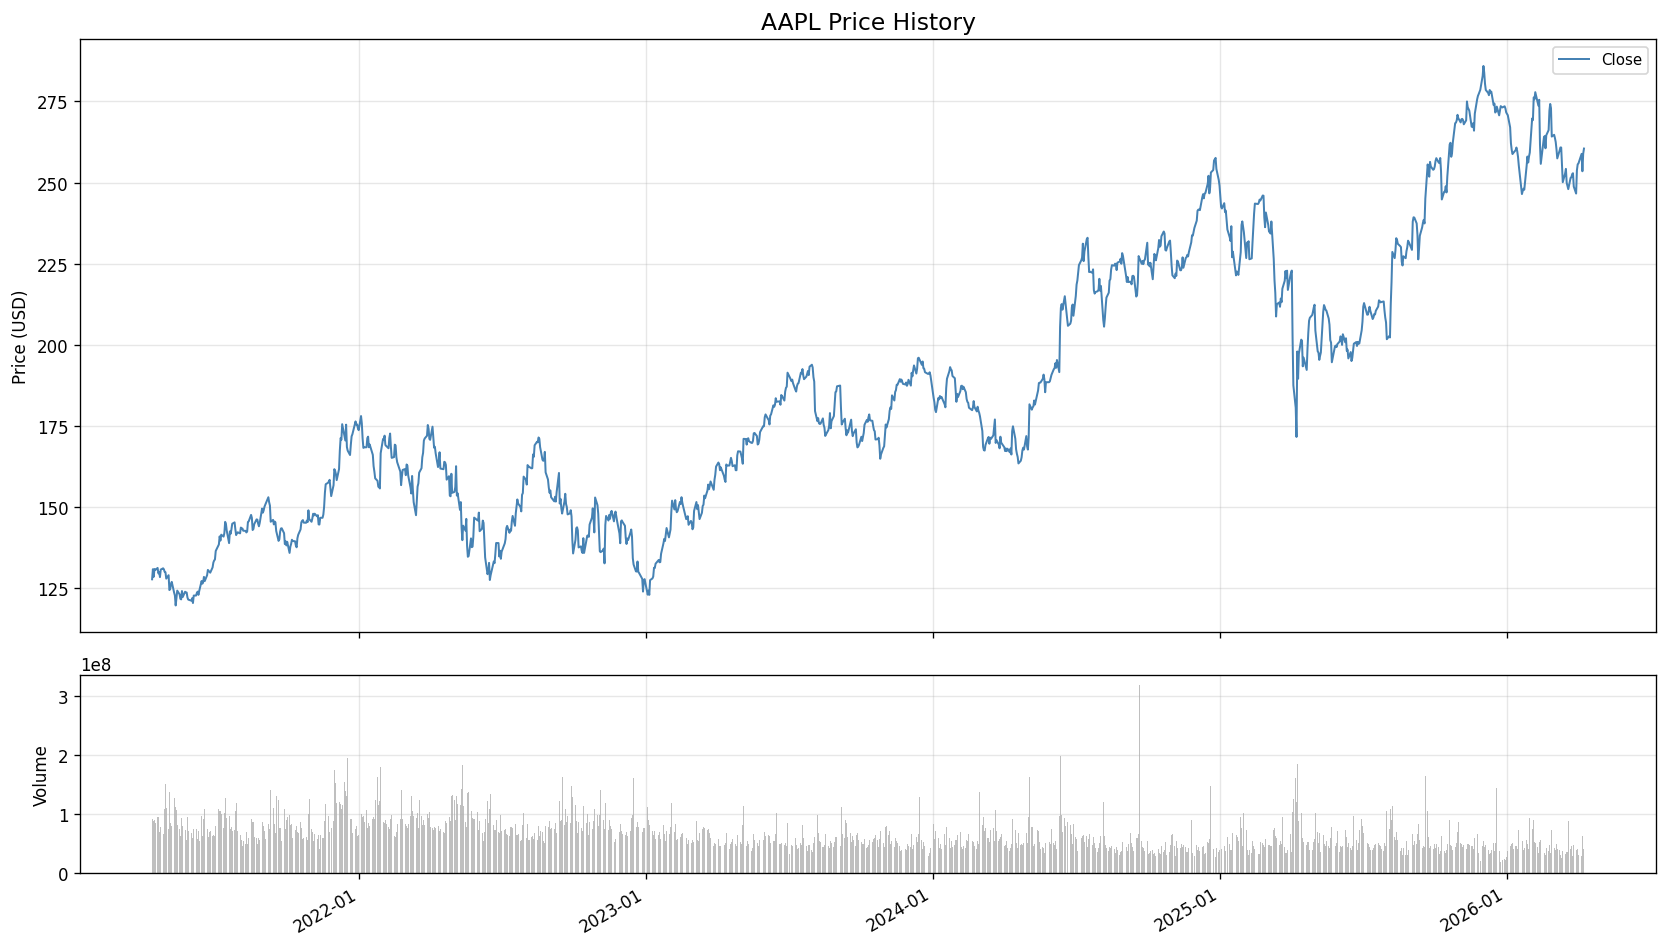

In [7]:
plot_price_history(raw, ticker=TICKER)

### 2b · Returns Distribution

Daily log-returns for most equities exhibit **excess kurtosis** (fat tails) and slight negative skewness — more extreme losses than a normal distribution would predict. The Q-Q plot visualises this deviation from normality.

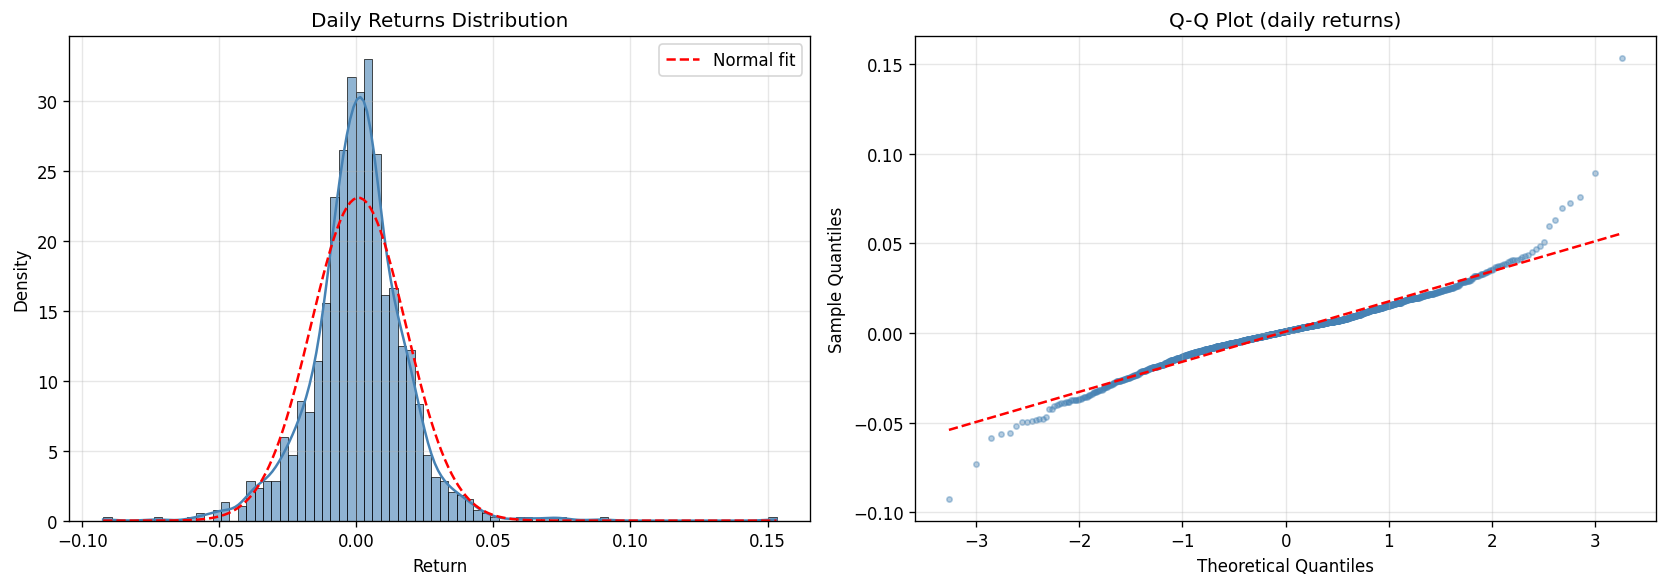

In [8]:
plot_returns_distribution(raw)

### 2c · Rolling Statistics

A non-stationary series has a time-varying mean or variance. Rolling mean drift and changing rolling std (volatility clustering) are both visible here.

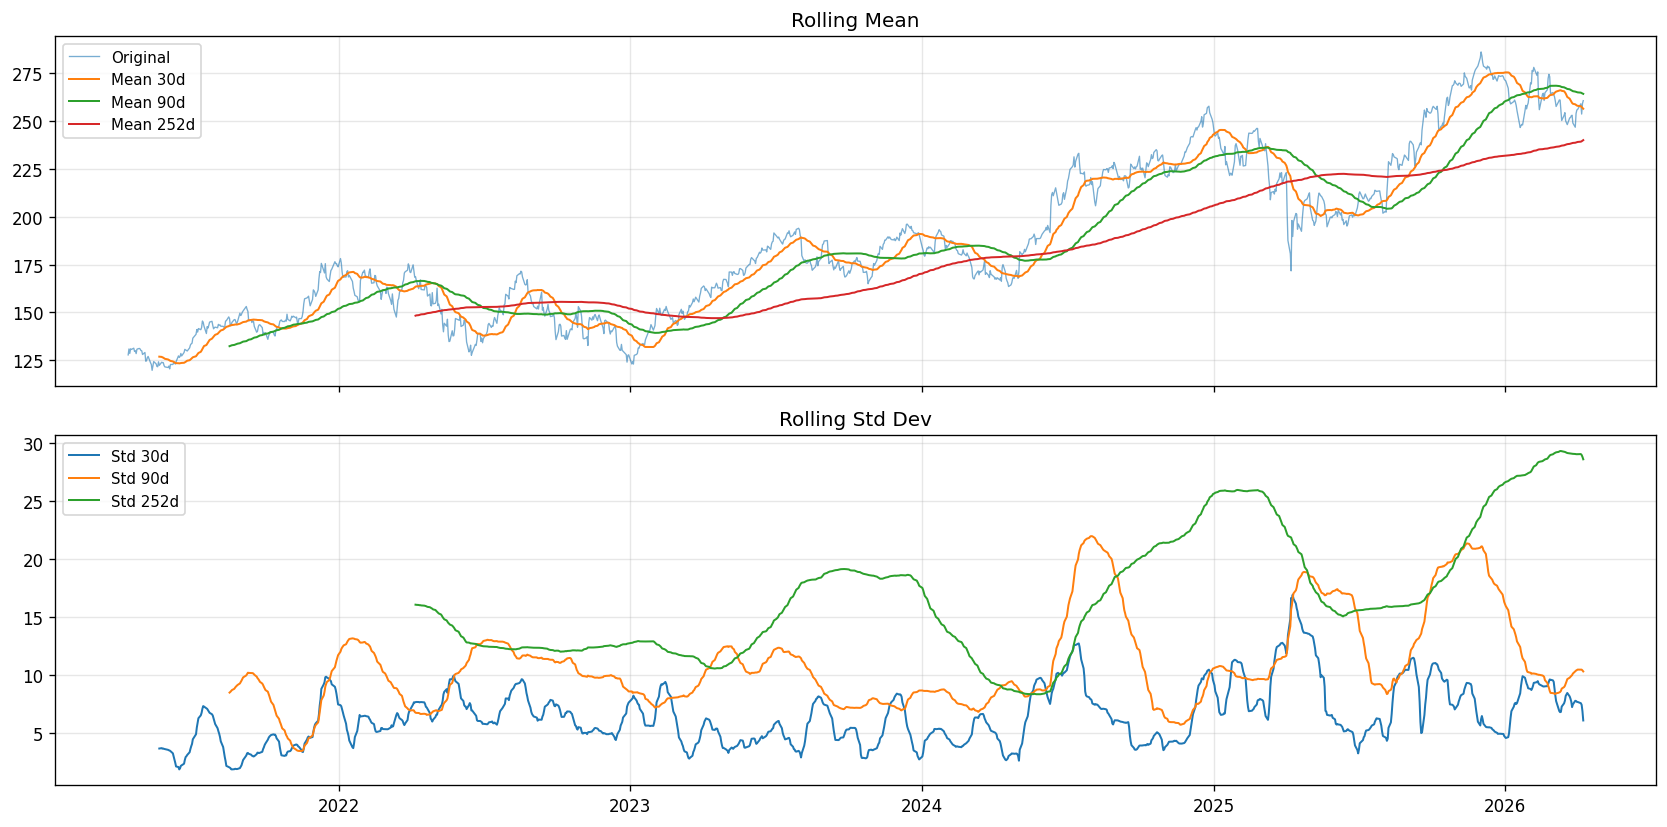

In [9]:
plot_rolling_stats(raw['Close'])

### 2d · Stationarity Tests

**ADF test** — H₀: unit root present (non-stationary). Reject H₀ if p-value < 0.05.

Raw closing prices are almost always non-stationary. First-differencing (or log-returns) typically achieves stationarity, which is why ARIMA uses the `d` parameter.

In [10]:
print('=== ADF Test — Close price (levels) ===')
_ = adf_test(raw['Close'])

print('\n=== ADF Test — 1-day returns ===')
_ = adf_test(raw['Close'].pct_change().dropna())

=== ADF Test — Close price (levels) ===
ADF Statistic     -1.1661
p-value            0.6880
Lags used               1
Observations         1253
Stationary (5%)     False
Critical 1%       -3.4356
Critical 5%       -2.8638
Critical 10%      -2.5680

=== ADF Test — 1-day returns ===
ADF Statistic     -34.7772
p-value             0.0000
Lags used                0
Observations          1253
Stationary (5%)       True
Critical 1%        -3.4356
Critical 5%        -2.8638
Critical 10%       -2.5680


### 2e · Autocorrelation (ACF / PACF)

These plots are the classic diagnostic for ARIMA order selection:
- Significant spikes in **PACF** at lag *k* → include AR(*k*) term.
- Gradual decay in **ACF**, sharp cutoff in PACF → pure AR process.
- We apply these to *returns*, not levels, since returns are stationary.

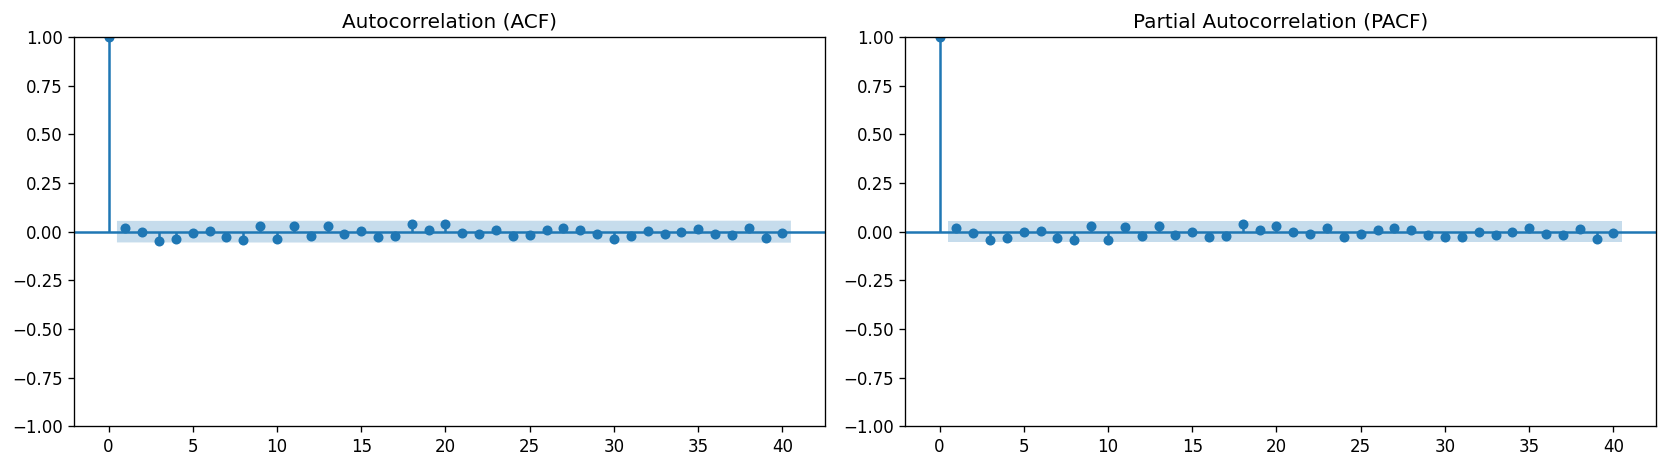

In [11]:
returns = raw['Close'].pct_change().dropna()
plot_acf_pacf(returns, lags=40)

### 2f · Seasonal Decomposition

Additive decomposition splits the series into **trend + seasonality + residual**. For daily stock data the seasonal period is set to 252 trading days (≈ 1 year). The residual component should look like white noise if the model captures all structure.

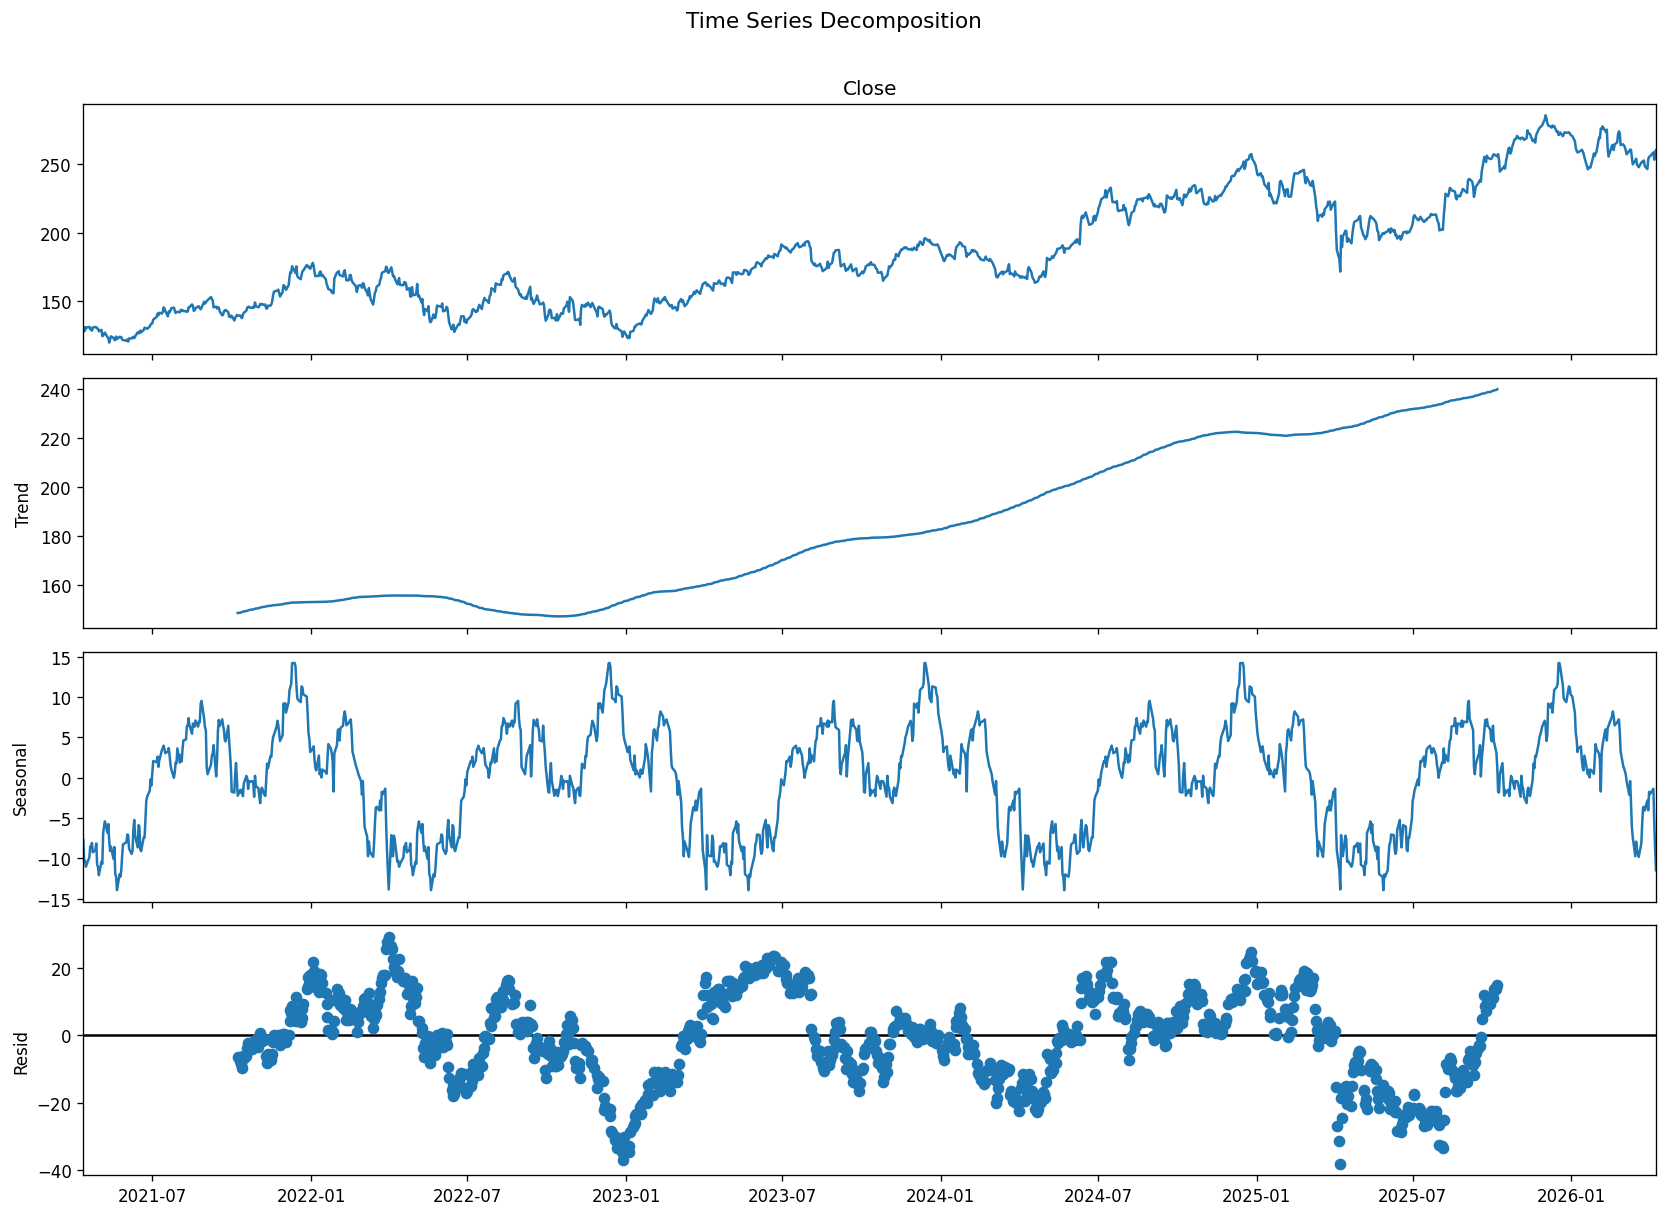

In [12]:
plot_decomposition(raw['Close'], period=252)

---
## 3 · Preprocessing

### Feature Engineering

We enrich the raw OHLCV data with standard technical indicators used in quantitative finance:

| Feature | Description |
|---|---|
| MA / EMA | Trend direction and momentum |
| RSI-14 | Overbought / oversold (0–100 oscillator) |
| MACD | Momentum: difference of 12-day and 26-day EMAs |
| Bollinger Bands | Volatility envelope around 20-day SMA |
| Returns (1d/5d/20d) | Short, medium, and long-term momentum |
| Lagged Close | Direct autoregressive features |

**ARIMA** uses only the raw close price series (it handles autocorrelation internally).
**XGBoost** and **LSTM** use all engineered features.

In [13]:
from src.preprocessing import (
    clean_data, add_technical_indicators, add_lag_features,
    prepare_ml_data, prepare_lstm_data,
)
from src.eda import plot_correlation_heatmap

df = clean_data(raw)
df = add_technical_indicators(df)
df = add_lag_features(df, col='Close')

print(f'Shape after feature engineering: {df.shape}')
df.head(3)

Shape after feature engineering: (1255, 32)


Price,Close,High,Low,Open,Volume,ticker,MA_7,MA_21,MA_50,MA_200,...,Return_20d,Volatility_20d,Volume_MA_20,Volume_ratio,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_5,Close_lag_10,Close_lag_20
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-12,127.8271,129.3953,127.2330,129.0738,91420000,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-04-13,130.9342,131.1582,128.4992,128.9960,91266500,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,127.8271,NaN,NaN,NaN,NaN,NaN
2021-04-14,128.5966,131.4894,128.2363,131.4310,87222800,AAPL,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,130.9342,127.8271,NaN,NaN,NaN,NaN


### 3b · Feature Selection & Correlation

High correlation between features (multicollinearity) is fine for LSTM and XGBoost but worth knowing about. The heatmap shows that MA/EMA features are highly correlated with Close — expected, since they are derived from it.

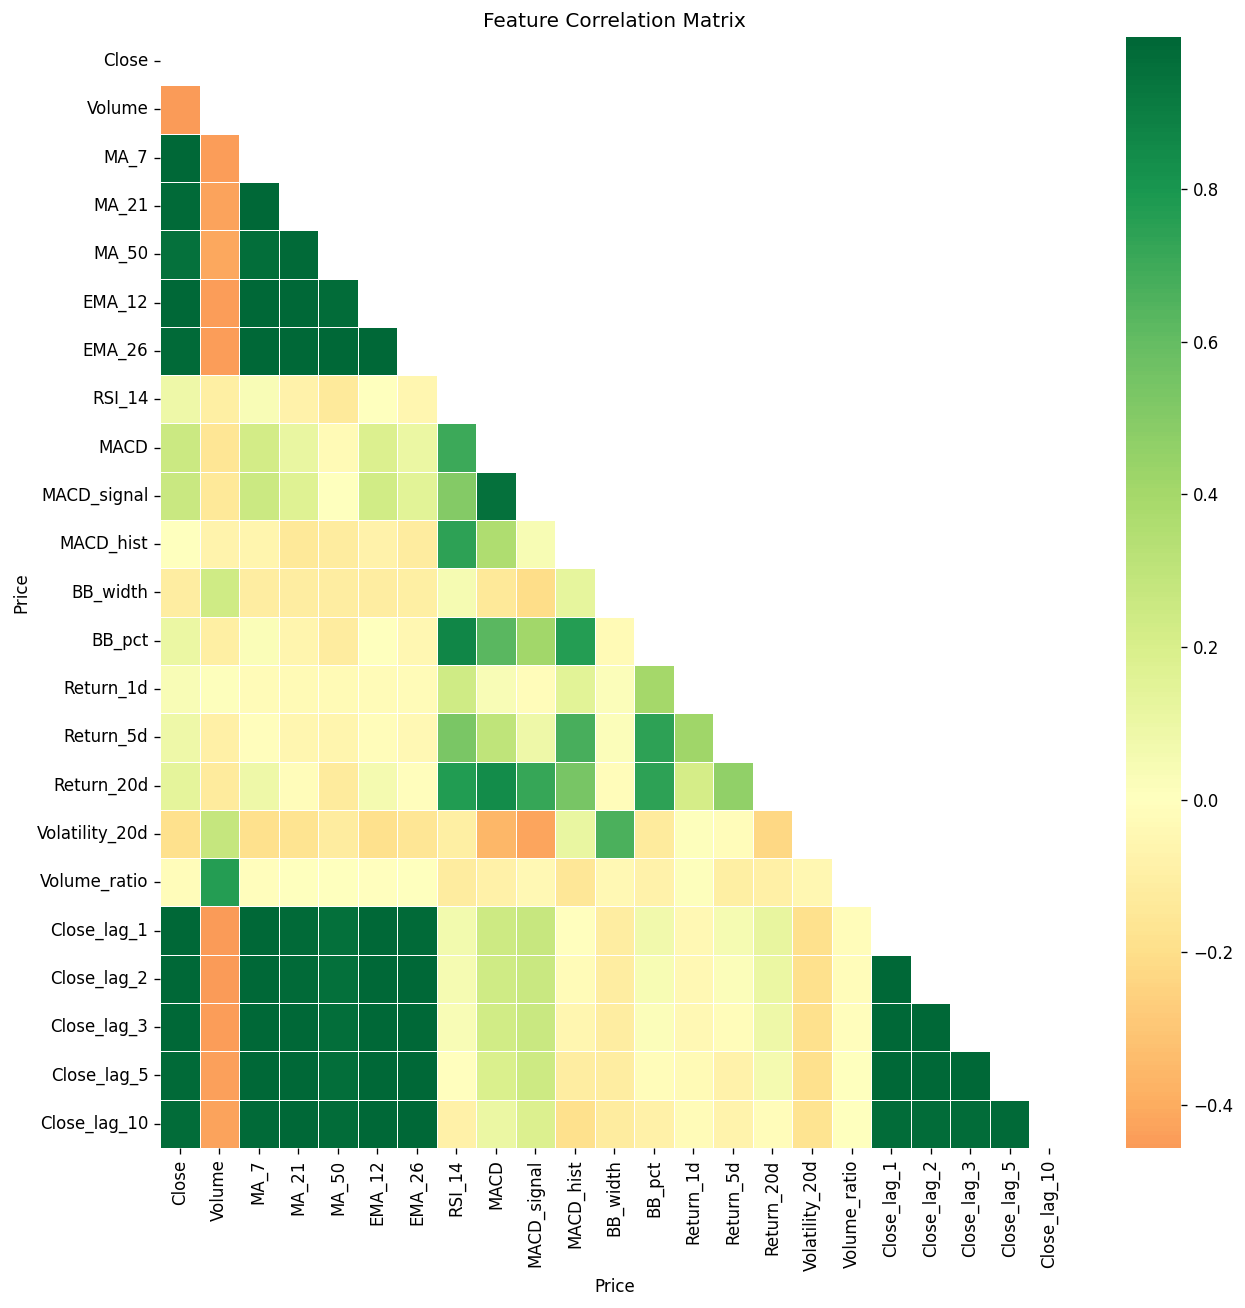

In [14]:
FEATURE_COLS = [
    'Close', 'Volume',
    'MA_7', 'MA_21', 'MA_50',
    'EMA_12', 'EMA_26',
    'RSI_14',
    'MACD', 'MACD_signal', 'MACD_hist',
    'BB_width', 'BB_pct',
    'Return_1d', 'Return_5d', 'Return_20d',
    'Volatility_20d',
    'Volume_ratio',
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3',
    'Close_lag_5', 'Close_lag_10',
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET_COL = 'Close'

plot_correlation_heatmap(df, cols=FEATURE_COLS)

### 3c · Train / Validation / Test Split

> **Important:** we use a strict **chronological split** — 70 % train · 15 % val · 15 % test.
> **Never** shuffle time-series data before splitting — this leaks future information into training.

| Split | Purpose | Approx. rows |
|---|---|---|
| **Train** (70 %) | Model fitting | `YEARS × 252 × 0.70` |
| **Validation** (15 %) | Early stopping, hyperparameter tuning | `YEARS × 252 × 0.15` |
| **Test** (15 %) | Final held-out evaluation — **touched only once** | `YEARS × 252 × 0.15` |

The scaler is **fit on training data only**, then applied to validation and test. Fitting on the full dataset would leak test-set statistics into the model (look-ahead bias).


In [15]:
ml_data = prepare_ml_data(df, FEATURE_COLS, target_col=TARGET_COL)
print('Flat feature matrix (XGBoost / ARIMA):')
print(f'  Train : {ml_data["X_train"].shape}')
print(f'  Val   : {ml_data["X_val"].shape}')
print(f'  Test  : {ml_data["X_test"].shape}')

Flat feature matrix (XGBoost / ARIMA):
  Train : (844, 23)
  Val   : (181, 23)
  Test  : (181, 23)


In [16]:
lstm_data = prepare_lstm_data(df, FEATURE_COLS, target_col=TARGET_COL, seq_len=SEQ_LEN)
print('Sequence tensor (LSTM):')
print(f'  Train : {lstm_data["X_train"].shape}  (samples × seq_len × features)')
print(f'  Val   : {lstm_data["X_val"].shape}')
print(f'  Test  : {lstm_data["X_test"].shape}')

Sequence tensor (LSTM):
  Train : (784, 60, 23)  (samples × seq_len × features)
  Val   : (121, 60, 23)
  Test  : (121, 60, 23)


---
## 4 · Model Training

We train three model types on the same training split and evaluate on the same test split, making the comparison fair.

### 4a · ARIMA

**ARIMA(p, d, q)** — Auto-Regressive Integrated Moving Average.
- **p** (AR): use the past *p* values to predict the next one.
- **d** (I): difference the series *d* times to achieve stationarity.
- **q** (MA): incorporate the past *q* forecast errors.

Baseline order (1, 1, 1) will be grid-searched in Section 5.

We use `(1, 1, 1)` as a sensible starting order:
- **p=1**: include the previous day's price (autoregressive term)
- **d=1**: first-difference the series to achieve stationarity (confirmed by ADF test)
- **q=1**: correct for one lag of the residual (moving-average term)

Section 5 will use an automatic grid search to find a better order.

In [17]:
from src.training import train_arima

train_series = ml_data['train_df']['Close']
ARIMA_ORDER  = (1, 1, 1)

arima_model = train_arima(train_series, order=ARIMA_ORDER)
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  844
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2048.168
Date:                Thu, 09 Apr 2026   AIC                           4102.336
Time:                        21:38:07   BIC                           4116.547
Sample:                             0   HQIC                          4107.781
                                - 844                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9108      0.064    -14.312      0.000      -1.035      -0.786
ma.L1          0.9415      0.052     17.933      0.000       0.839       1.044
sigma2         7.5481      0.260     28.986      0.0

/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


#### Generating test-set forecasts

We call `forecast(steps=n_test)` to produce a direct multi-step forecast over the entire test window.
Note: this is *not* a walk-forward forecast — the model is fit once on training data and then asked to predict all future steps at once. Walk-forward evaluation (refitting at each step) is available via `evaluation.walk_forward_validation()` but is much slower.

In [18]:
n_test         = len(ml_data['test_df'])
arima_forecast = arima_model.forecast(steps=n_test).values
arima_true     = ml_data['y_test_raw']
print(f'Forecast shape: {arima_forecast.shape}')

Forecast shape: (181,)


/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 4b · XGBoost

XGBoost frames forecasting as a **supervised regression** problem: given today's feature vector (technical indicators + lagged prices), predict tomorrow's close.

Key hyperparameters (to be tuned in Section 5):
- `max_depth`: tree depth — higher → more capacity, more overfitting risk.
- `learning_rate`: shrinkage factor — lower → more robust, needs more trees.
- `subsample` / `colsample_bytree`: row/column subsampling for regularisation.

Early stopping on the validation loss prevents overfitting automatically.

#### Key default hyperparameters

| Parameter | Value | Why |
|---|---|---|
| `n_estimators` | 500 | Max trees; early stopping reduces this |
| `max_depth` | 6 | Moderate tree depth to prevent overfitting |
| `learning_rate` | 0.05 | Slow learning → better generalisation |
| `subsample` | 0.8 | Row subsampling adds stochasticity |
| `early_stopping_rounds` | 30 | Stop if validation loss does not improve |

Section 5 will use Optuna to search all of these simultaneously.

In [19]:
from src.training import train_xgboost
from src.evaluation import inverse_scale

xgb_model = train_xgboost(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'],   ml_data['y_val'],
)
xgb_pred = inverse_scale(xgb_model.predict(ml_data['X_test']), ml_data['target_scaler'])
xgb_true = ml_data['y_test_raw']
print(f'XGBoost done. Best iteration: {xgb_model.best_iteration}')

XGBoost done. Best iteration: 264


### 4c · LSTM

The **LSTM (Long Short-Term Memory)** network processes the last `SEQ_LEN` trading days as a sequence. Unlike XGBoost, it does not need manual lag features — it learns which past timesteps matter.

Architecture:
```
Input (SEQ_LEN × n_features)
  → LSTM(64, return_sequences=True) + Dropout(0.2)
  → LSTM(32) + Dropout(0.2)
  → Dense(16, relu)
  → Dense(1)   ← predicted next-day close
```
Training uses **EarlyStopping** (stops when val_loss stops improving) and **ReduceLROnPlateau** (halves the learning rate on plateaus).

#### Building the LSTM

The network follows this architecture:

```
Input  →  LSTM(64, return_sequences=True)
       →  Dropout(0.2)
       →  LSTM(32, return_sequences=False)
       →  Dropout(0.2)
       →  Dense(16, relu)
       →  Dense(1)       ← single-step forecast output
```

`return_sequences=True` on the first LSTM layer passes the full hidden-state sequence to the second layer (needed for stacking). The final LSTM has `return_sequences=False` so only the last hidden state is passed to the Dense head.

In [20]:
from src.training import build_lstm, train_lstm

input_shape = lstm_data['X_train'].shape[1:]   # (SEQ_LEN, n_features)
lstm_model  = build_lstm(input_shape=input_shape, units=(64, 32), dropout=0.2)
lstm_model.summary()

I0000 00:00:1775770698.274227  110640 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775770699.893503  110640 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,489 (138.63 KB)

 Trainable params: 35,489 (138.63 KB)

 Non-trainable params: 0 (0.00 B)

#### Training callbacks

Two callbacks control the training loop:

- **EarlyStopping** (`patience=15`) — halts training if `val_loss` has not improved for 15 epochs, then restores the weights from the best epoch. This prevents overfitting.
- **ReduceLROnPlateau** (`factor=0.5, patience=7`) — halves the learning rate when the validation loss plateaus. Allows fine-grained convergence after the initial rapid descent.

Training progress is printed per epoch. Look at the gap between `loss` and `val_loss` — a widening gap signals overfitting.

In [21]:
lstm_model, lstm_history = train_lstm(
    lstm_model,
    lstm_data['X_train'], lstm_data['y_train'],
    lstm_data['X_val'],   lstm_data['y_val'],
    epochs=100, batch_size=32, patience=15,
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0397 - mae: 0.1425 - val_loss: 0.0137 - val_mae: 0.0858 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0114 - mae: 0.0825 - val_loss: 0.0131 - val_mae: 0.0813 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0085 - mae: 0.0712 - val_loss: 0.0207 - val_mae: 0.1109 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0075 - mae: 0.0661 - val_loss: 0.0098 - val_mae: 0.0689 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0060 - mae: 0.0611 - val_loss: 0.0109 - val_mae: 0.0826 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0059 - mae: 0.0596 - val_loss: 0.0088 - val_mae: 0.0686 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0049 - mae: 0.0543 - val_loss: 0.0074 - val_mae: 0.0579 - learning_rate: 0.0010
Epoch 

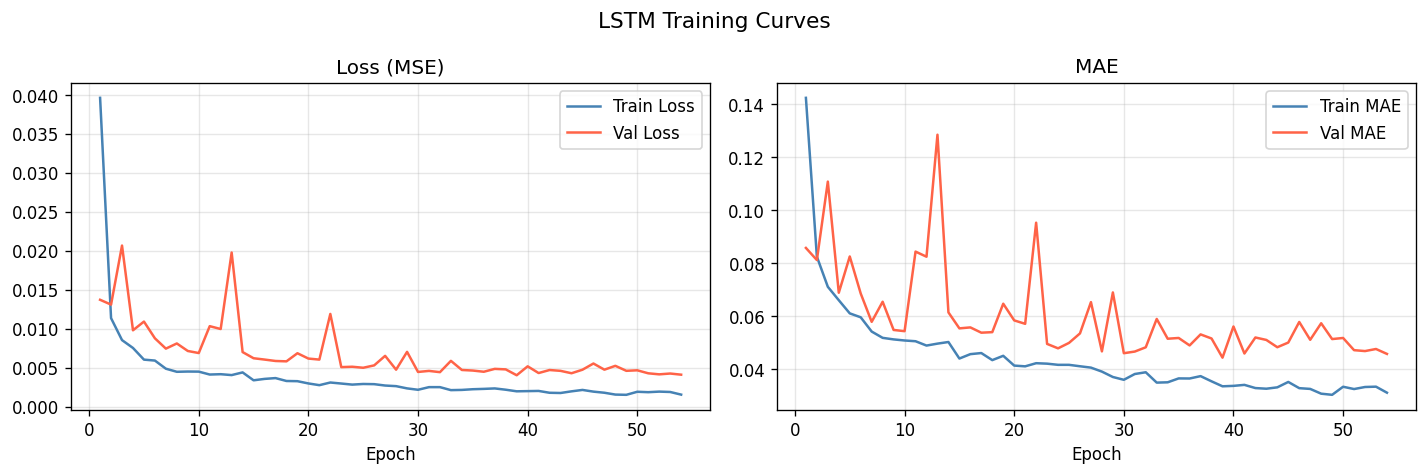

In [22]:
from src.visualization import plot_loss_curves
plot_loss_curves(lstm_history)

#### Inverse-scaling LSTM predictions

The LSTM was trained on MinMax-scaled data. To get predictions back in USD we reverse the transform using the same scaler fitted on training data.

In [23]:
scaler     = lstm_data['scaler']
target_idx = lstm_data['target_idx']
n_features = len(lstm_data['all_cols'])

def _invert_lstm(pred_scaled, scaler, target_idx, n_features):
    """Reconstruct original-scale values from a scaled target column."""
    dummy = np.zeros((len(pred_scaled), n_features))
    dummy[:, target_idx] = pred_scaled
    return scaler.inverse_transform(dummy)[:, target_idx]

lstm_pred = _invert_lstm(lstm_model.predict(lstm_data['X_test']).ravel(), scaler, target_idx, n_features)
lstm_true = _invert_lstm(lstm_data['y_test'], scaler, target_idx, n_features)
print('LSTM predictions ready.')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
LSTM predictions ready.


---
## 5 · Hyperparameter Fine-Tuning

Tuning strategies differ by model type:

| Model | Strategy | What is optimised |
|---|---|---|
| ARIMA | **Grid search** over (p, d, q) | Akaike Information Criterion (AIC) |
| XGBoost | **Optuna** Bayesian (TPE) | Validation RMSE |
| LSTM | **Optuna** Bayesian (TPE) | Validation MSE loss |

> **Important:** tuning uses **training + validation data only**. The test set is never seen. Once the best parameters are found, models are re-trained and evaluated on the test set in Section 6.

Optuna trials run sequentially. Reduce `n_trials` if you want faster results; increase it for better coverage of the search space.


### 5a · ARIMA — Grid Search

In [24]:
from src.fine_tuning import tune_arima

best_arima_order, arima_search = tune_arima(
    train_series, p_values=[0,1,2], d_values=[0,1], q_values=[0,1,2]
)
arima_search.head(5)

ARIMA(0, 0, 0)  AIC=7874.34
ARIMA(0, 0, 1)  AIC=6812.25
ARIMA(0, 0, 2)  AIC=6070.65
ARIMA(0, 1, 0)  AIC=4102.94
ARIMA(0, 1, 1)  AIC=4104.40
ARIMA(0, 1, 2)  AIC=4104.42
ARIMA(1, 0, 0)  AIC=4116.14
ARIMA(1, 0, 1)  AIC=4117.50
ARIMA(1, 0, 2)  AIC=4117.74
ARIMA(1, 1, 0)  AIC=4104.45
ARIMA(1, 1, 1)  AIC=4102.34
ARIMA(1, 1, 2)  AIC=4106.16
ARIMA(2, 0, 0)  AIC=4117.56
ARIMA(2, 0, 1)  AIC=4115.49
ARIMA(2, 0, 2)  AIC=4119.52
ARIMA(2, 1, 0)  AIC=4104.27
ARIMA(2, 1, 1)  AIC=4106.02
ARIMA(2, 1, 2)  AIC=4107.52

Best order: ARIMA(1, 1, 1)  (AIC=4102.34)


,order,AIC,BIC
0,"(1, 1, 1)",4102.3358,4116.5467
1,"(0, 1, 0)",4102.9365,4107.6734
2,"(2, 1, 0)",4104.2659,4118.4768
3,"(0, 1, 1)",4104.3975,4113.8715
4,"(0, 1, 2)",4104.4221,4118.6330


In [25]:
arima_model_tuned    = train_arima(train_series, order=best_arima_order)
arima_forecast_tuned = arima_model_tuned.forecast(steps=n_test).values
print(f'Best ARIMA order: {best_arima_order}')

/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Best ARIMA order: (1, 1, 1)


/workspaces/Time-Series-Forecasting-S-P-500/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 5b · XGBoost — Optuna

Optuna uses **Tree-structured Parzen Estimators (TPE)** to intelligently sample the search space. Each trial trains a model and reports validation RMSE; the sampler steers toward promising regions.

In [26]:
from src.fine_tuning import tune_xgboost

best_xgb_params, xgb_study = tune_xgboost(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'],   ml_data['y_val'],
    n_trials=30,
)
print('Best XGB params:', best_xgb_params)

[I 2026-04-09 21:40:17,667] A new study created in memory with name: no-name-fff04122-187d-4d29-b77d-1ae0fe1126a3
[I 2026-04-09 21:40:18,569] Trial 0 finished with value: 0.004714192374111186 and parameters: {'n_estimators': 936, 'max_depth': 7, 'learning_rate': 0.05482222998685506, 'subsample': 0.699729595966727, 'colsample_bytree': 0.7229295913440077, 'min_child_weight': 10, 'reg_alpha': 0.0011877658445402612, 'reg_lambda': 1.3389427992389783e-05}. Best is trial 0 with value: 0.004714192374111186.
[I 2026-04-09 21:40:23,554] Trial 1 finished with value: 0.010891492623041864 and parameters: {'n_estimators': 869, 'max_depth': 9, 'learning_rate': 0.0024145737452496096, 'subsample': 0.5033689993462058, 'colsample_bytree': 0.6671300488020353, 'min_child_weight': 4, 'reg_alpha': 2.0345009645709184e-05, 'reg_lambda': 2.0899007462522378e-05}. Best is trial 0 with value: 0.004714192374111186.
[I 2026-04-09 21:40:23,787] Trial 2 finished with value: 0.004794949817624738 and parameters: {'n_est

Best XGB RMSE: 0.056624
Best XGB params: {'n_estimators': 688, 'max_depth': 8, 'learning_rate': 0.14008016565551462, 'subsample': 0.6554173996636077, 'colsample_bytree': 0.9540427230843787, 'min_child_weight': 2, 'reg_alpha': 0.00017579975026585926, 'reg_lambda': 8.775575714702201}


In [27]:
xgb_model_tuned = train_xgboost(
    ml_data['X_train'], ml_data['y_train'],
    ml_data['X_val'],   ml_data['y_val'],
    params=best_xgb_params,
)
xgb_pred_tuned = inverse_scale(xgb_model_tuned.predict(ml_data['X_test']), ml_data['target_scaler'])

### 5c · LSTM — Optuna

We search over layer sizes, dropout rate, learning rate, and batch size. Each trial runs up to `max_epochs` with early stopping, so fast trials exit quickly.

In [28]:
from src.fine_tuning import tune_lstm

best_lstm_params, lstm_study = tune_lstm(
    lstm_data['X_train'], lstm_data['y_train'],
    lstm_data['X_val'],   lstm_data['y_val'],
    n_trials=15, max_epochs=50,
)
print('Best LSTM params:', best_lstm_params)

[I 2026-04-09 21:40:50,974] A new study created in memory with name: no-name-c3ad011d-0538-4648-aae1-b3eb3d1d6eda
[I 2026-04-09 21:41:19,372] Trial 0 finished with value: 0.004581226967275143 and parameters: {'units_1': 32, 'units_2': 64, 'dropout': 0.11719985399747657, 'learning_rate': 0.0009071288759722449, 'batch_size': 64}. Best is trial 0 with value: 0.004581226967275143.
[I 2026-04-09 21:41:39,041] Trial 1 finished with value: 0.010556747205555439 and parameters: {'units_1': 32, 'units_2': 16, 'dropout': 0.4944690568042659, 'learning_rate': 0.0004088716244720912, 'batch_size': 64}. Best is trial 0 with value: 0.004581226967275143.
[I 2026-04-09 21:42:33,317] Trial 2 finished with value: 0.003828778164461255 and parameters: {'units_1': 64, 'units_2': 64, 'dropout': 0.11109375675552978, 'learning_rate': 0.0006732563403039119, 'batch_size': 32}. Best is trial 2 with value: 0.003828778164461255.
[I 2026-04-09 21:43:12,037] Trial 3 finished with value: 0.005549142602831125 and paramet

Best LSTM val_loss: 0.002728
Best LSTM params: {'units_1': 64, 'units_2': 32, 'dropout': 0.20648403994640957, 'learning_rate': 0.009902231344174253, 'batch_size': 16}


In [29]:
lstm_model_tuned = build_lstm(
    input_shape=input_shape,
    units=(int(best_lstm_params["units_1"]), int(best_lstm_params["units_2"])),
    dropout=float(best_lstm_params["dropout"]),
    learning_rate=float(best_lstm_params["learning_rate"]),
)
lstm_model_tuned, lstm_history_tuned = train_lstm(
    lstm_model_tuned,
    lstm_data["X_train"], lstm_data["y_train"],
    lstm_data["X_val"],   lstm_data["y_val"],
    epochs=100, batch_size=int(best_lstm_params["batch_size"]),
)
lstm_pred_tuned = _invert_lstm(
    lstm_model_tuned.predict(lstm_data["X_test"]).ravel(),
    scaler, target_idx, n_features,
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0397 - mae: 0.1131 - val_loss: 0.0084 - val_mae: 0.0629 - learning_rate: 0.0099
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0066 - mae: 0.0621 - val_loss: 0.0101 - val_mae: 0.0785 - learning_rate: 0.0099
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0038 - mae: 0.0490 - val_loss: 0.0090 - val_mae: 0.0814 - learning_rate: 0.0099
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0031 - mae: 0.0425 - val_loss: 0.0074 - val_mae: 0.0640 - learning_rate: 0.0099
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0029 - mae: 0.0418 - val_loss: 0.0058 - val_mae: 0.0559 - learning_rate: 0.0099
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0032 - mae: 0.0442 - val_loss: 0.0063 - val_mae: 0.0582 - learning_rate: 0.0099
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0025 - mae: 0.0398 - val_loss: 0.0093 - val_mae: 0.0844 - learning_rate: 0.0099
Epoch 

---
## 6 · Evaluation

All models are evaluated on the **held-out test set** (the final 15% of data, never seen during training).

| Metric | Formula | Interpretation |
|---|---|---|
| MAE | mean\|y − ŷ\| | Average error in USD — easy to interpret |
| RMSE | √mean(y − ŷ)² | Penalises large errors more than MAE |
| MAPE | mean\|y − ŷ\|/y × 100 | Scale-independent percentage error |
| R² | 1 − SS_res/SS_tot | 1.0 = perfect; 0.0 = predicts the mean |
| Dir. Acc | % correct direction | Did the model predict up/down correctly? |

#### Computing all metrics

We evaluate both the *default* and *tuned* variants of each model so you can quantify the benefit of hyperparameter optimisation. Results are collected into `results`, then formatted as a comparison table below.

> **Tip:** look at **Directional Accuracy** (last column) — values above 0.52 are meaningful for trading signals on daily price data.

In [30]:
from src.evaluation import compute_metrics, compare_models

results = [
    compute_metrics(arima_true, arima_forecast,       'ARIMA (default)'),
    compute_metrics(arima_true, arima_forecast_tuned, 'ARIMA (tuned)'),
    compute_metrics(xgb_true,   xgb_pred,             'XGBoost (default)'),
    compute_metrics(xgb_true,   xgb_pred_tuned,       'XGBoost (tuned)'),
    compute_metrics(lstm_true,  lstm_pred,             'LSTM (default)'),
    compute_metrics(lstm_true,  lstm_pred_tuned,       'LSTM (tuned)'),
]

compare_models(results)

,MAE,RMSE,MAPE,SMAPE,R²,Dir.Acc
Model,,,,,,
LSTM (default),19.8066,20.6434,7.4196,7.7272,-3.5725,0.5833
LSTM (tuned),23.7161,25.0118,8.8601,9.3124,-5.7124,0.5583
XGBoost (tuned),23.2940,27.6268,8.7680,9.3331,-1.1025,0.6500
XGBoost (default),24.0118,28.3333,9.0462,9.6421,-1.2114,0.7833
ARIMA (default),27.7680,31.1770,10.6205,11.2926,-1.6776,0.5389
ARIMA (tuned),27.7680,31.1770,10.6205,11.2926,-1.6776,0.5389


---
## 7 · Visualization

Numbers alone don't tell the full story. Visual inspection reveals systematic biases (always undershooting peaks), lag effects, or volatility mis-estimation that summary metrics can mask.

In [ ]:
from src.visualization import (
    plot_forecast, plot_forecast_with_history,
    plot_model_comparison, plot_loss_curves,
    plot_feature_importance, plot_residuals,
    plot_candlestick, plot_forecast_interactive,
)

# Boundary dates for full-history charts
train_end_date  = ml_data['train_df'].index[-1]
val_end_date    = ml_data['val_df'].index[-1]

# Test-window date indexes
test_dates      = ml_data['test_df'].index
lstm_test_dates = ml_data['test_df'].index[SEQ_LEN:]


### 7a · Forecast vs Actual

Two complementary views per model:

**Full-history view** — the entire price series is shown with three colour-coded bands:
- 🔵 **Blue band** = training window (model saw this data)
- 🟠 **Orange band** = validation window (used for early stopping & tuning)
- 🟢 **Green band** = test window (never seen during training)

The dashed vertical lines mark the exact cut-off dates. The coloured overlay on the test portion shows Actual (solid) vs Predicted (dashed). The bottom panel shows signed residuals (positive = under-prediction, negative = over-prediction).

**Test-only zoom** — a tighter chart focusing only on the test period so small differences are visible.


In [ ]:
plot_forecast_with_history(
    df['Close'], arima_true, arima_forecast_tuned,
    train_end_date, val_end_date,
    dates_test=test_dates,
    title=f'ARIMA (tuned) — Full History + Test Forecast — {TICKER}',
)

In [ ]:
plot_forecast_with_history(
    df['Close'], xgb_true, xgb_pred_tuned,
    train_end_date, val_end_date,
    dates_test=test_dates,
    title=f'XGBoost (tuned) — Full History + Test Forecast — {TICKER}',
)

In [ ]:
plot_forecast_with_history(
    df['Close'], lstm_true, lstm_pred_tuned,
    train_end_date, val_end_date,
    dates_test=lstm_test_dates,
    title=f'LSTM (tuned) — Full History + Test Forecast — {TICKER}',
)

#### Test-window zoom

The following charts focus exclusively on the test period, making it easier to assess day-to-day prediction accuracy and detect systematic biases (e.g. always lagging by one day, or consistently under-shooting price spikes).

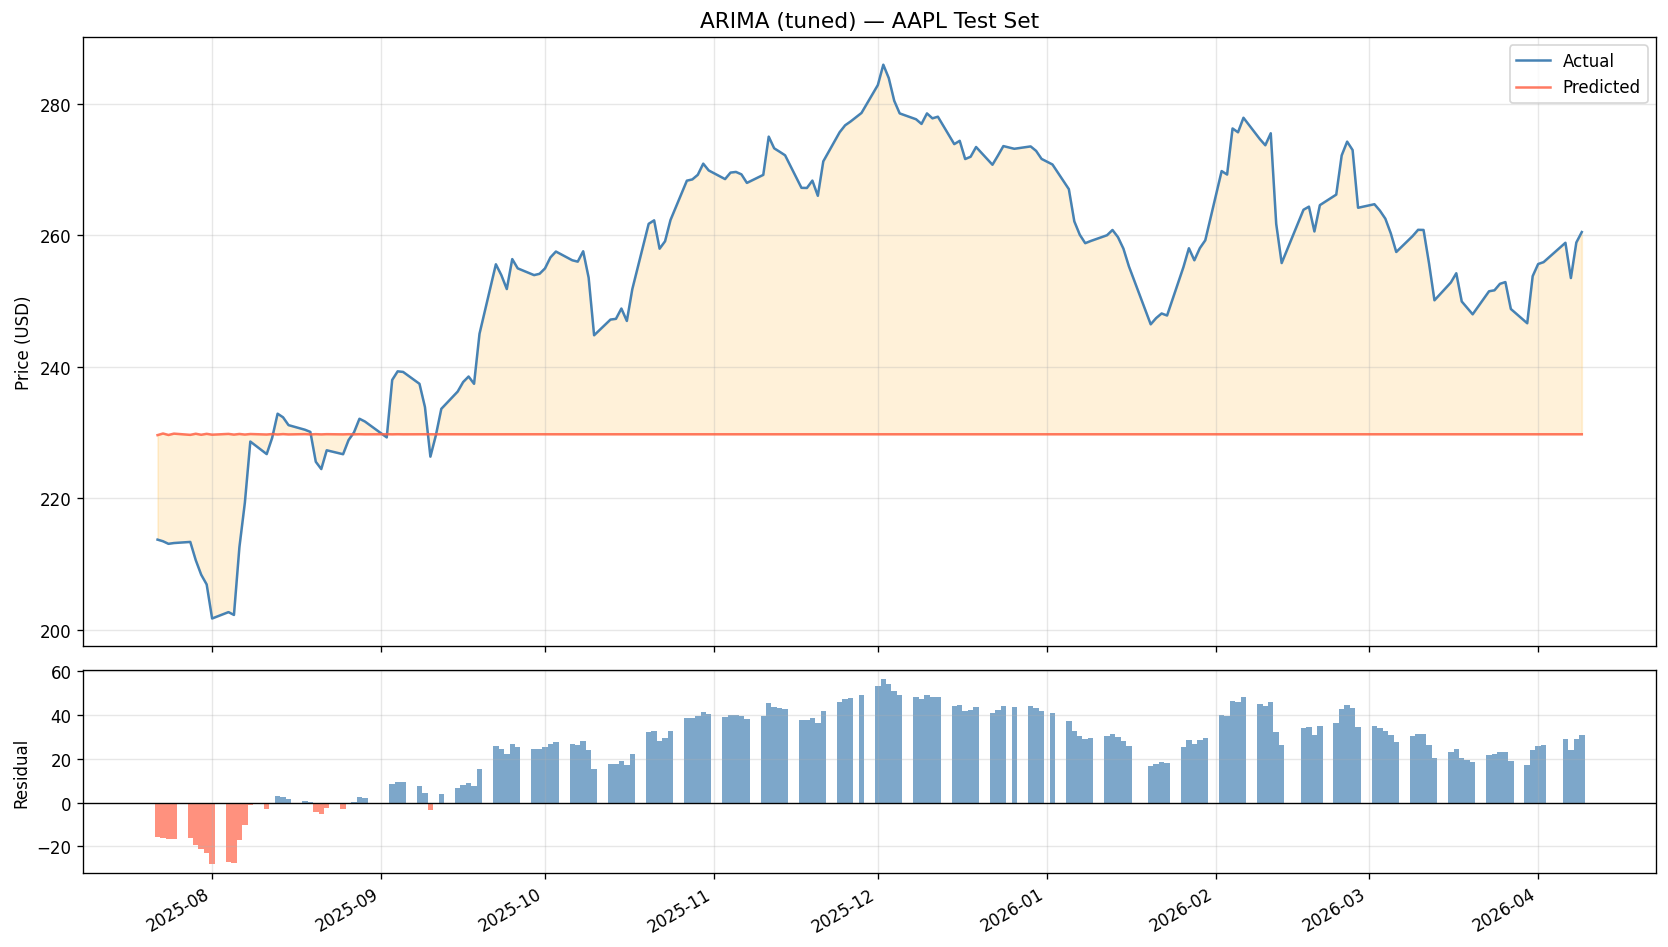

In [32]:
plot_forecast(arima_true, arima_forecast_tuned, dates=test_dates, title=f'ARIMA (tuned) — {TICKER} Test Set')

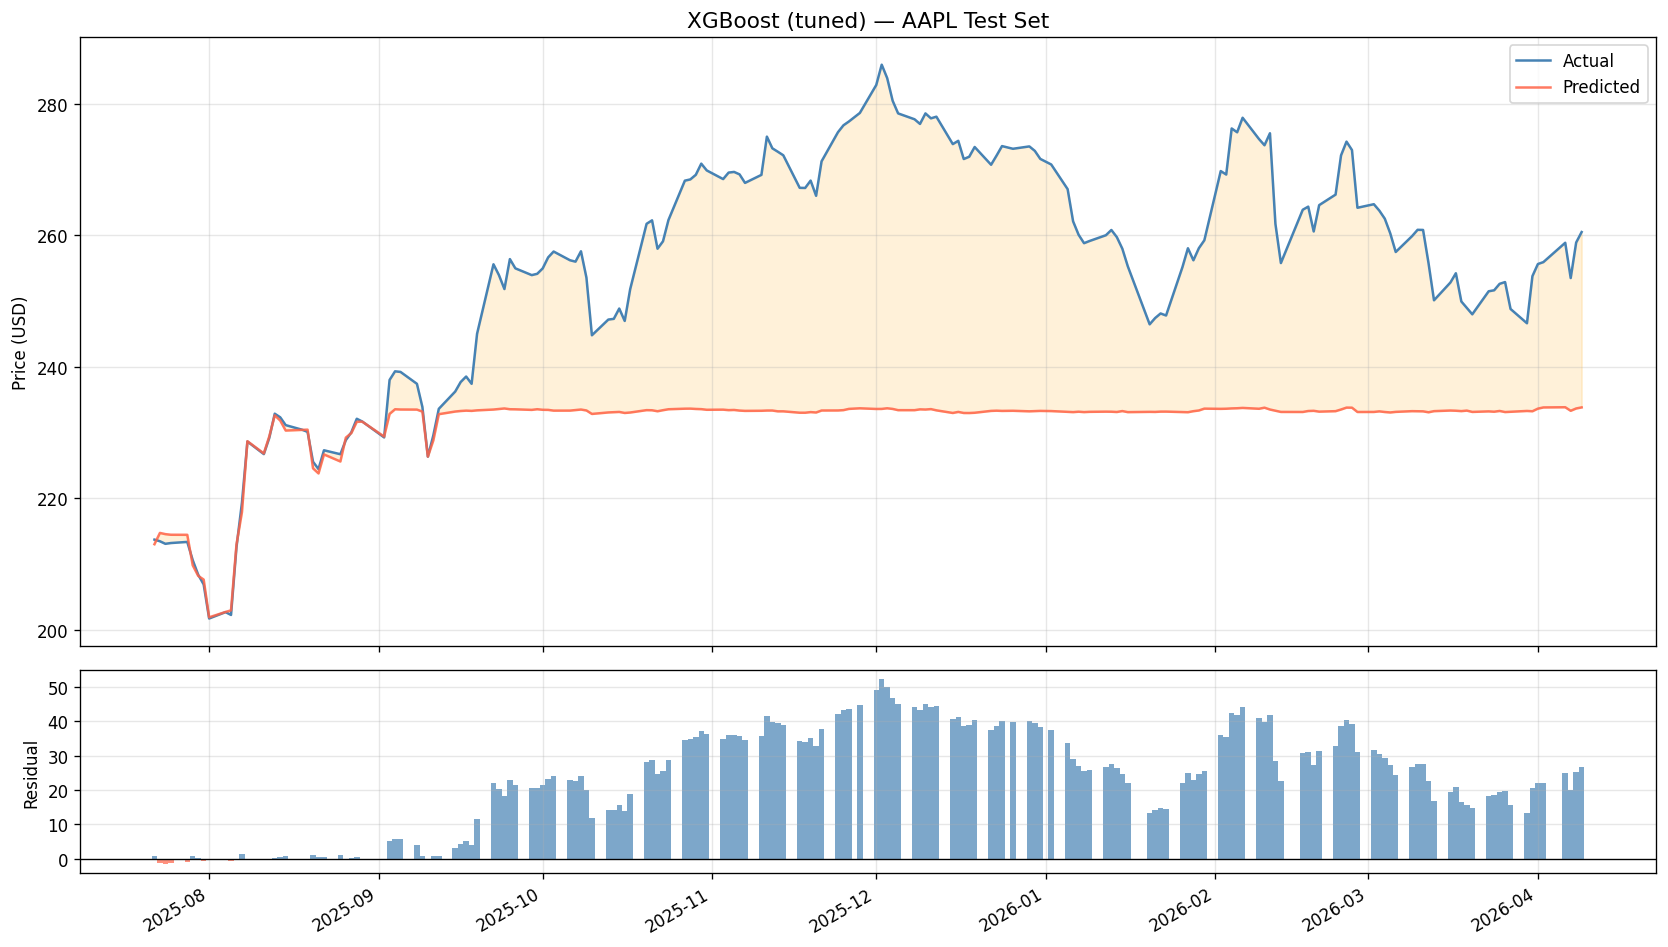

In [33]:
plot_forecast(xgb_true, xgb_pred_tuned, dates=test_dates, title=f'XGBoost (tuned) — {TICKER} Test Set')

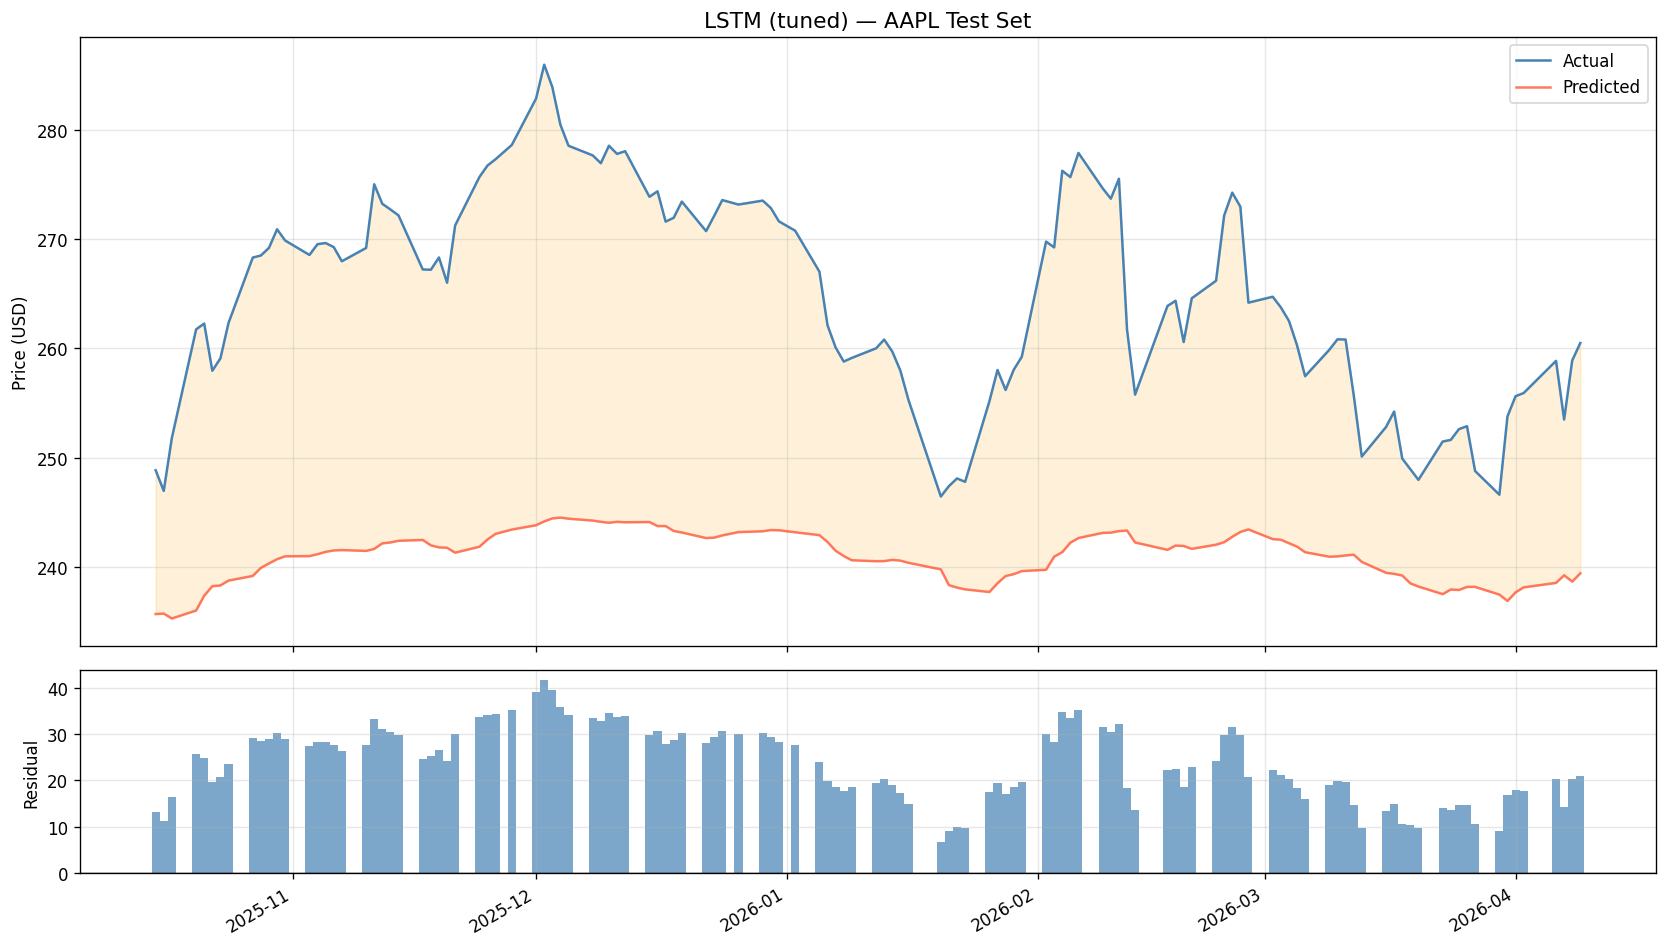

In [34]:
plot_forecast(lstm_true, lstm_pred_tuned, dates=lstm_test_dates, title=f'LSTM (tuned) — {TICKER} Test Set')

### 7b · Model Comparison

Side-by-side bar charts across all metrics make it easy to see which model excels on which criterion.

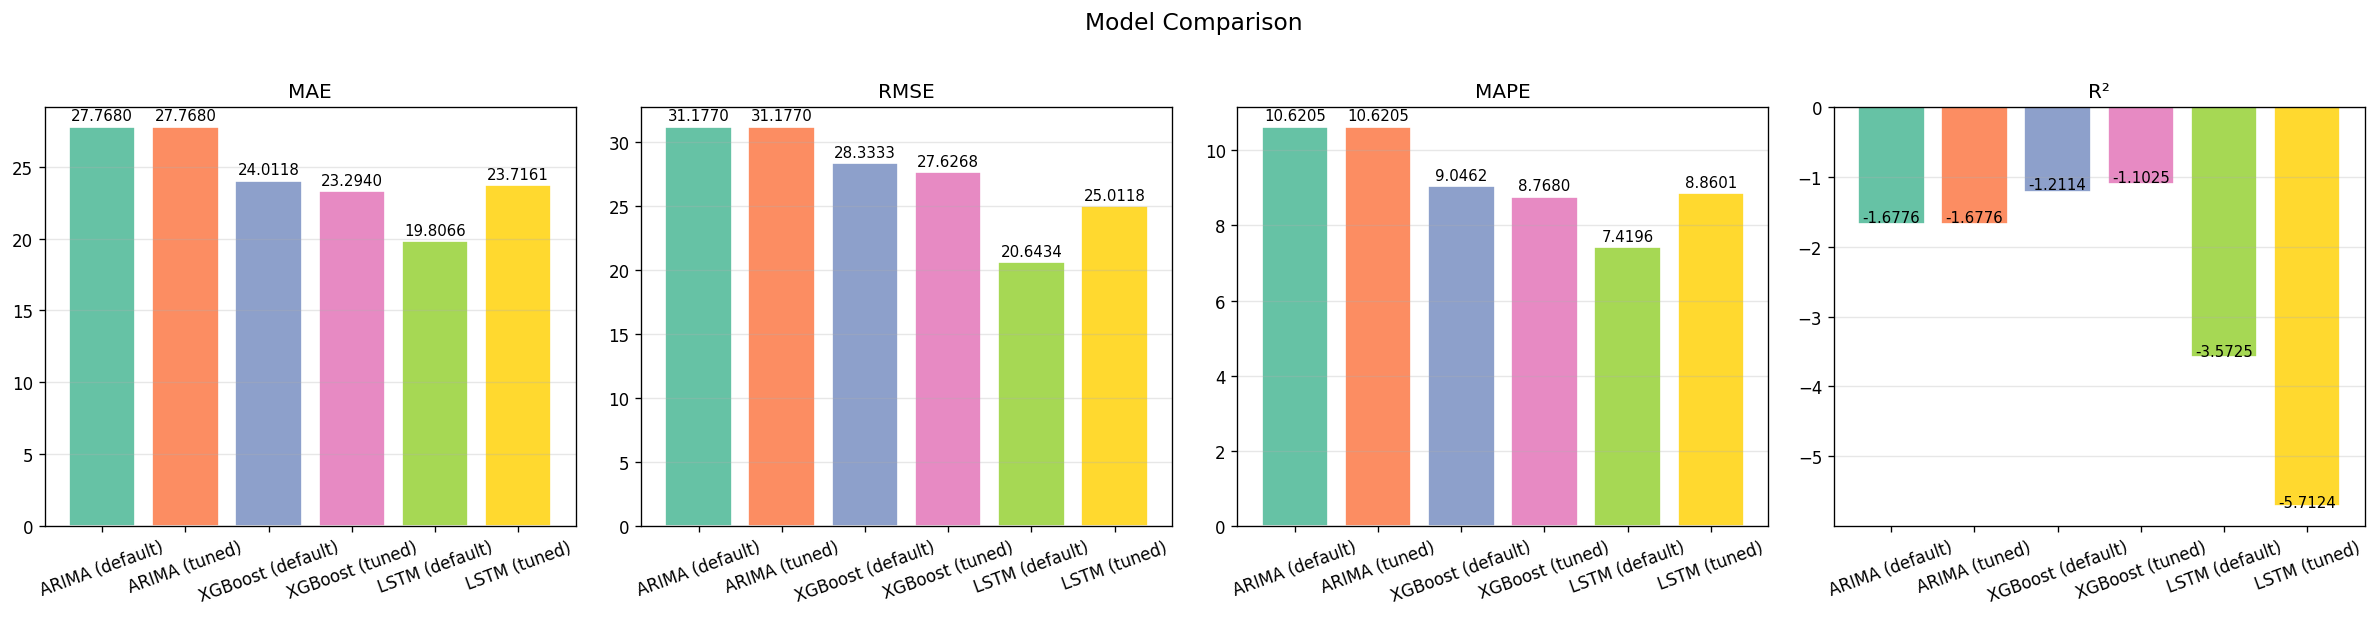

In [35]:
plot_model_comparison(results)

### 7c · XGBoost Feature Importance

XGBoost reports how often each feature is used in a tree split (gain). This tells us which technical indicators carry the most predictive signal for this ticker.

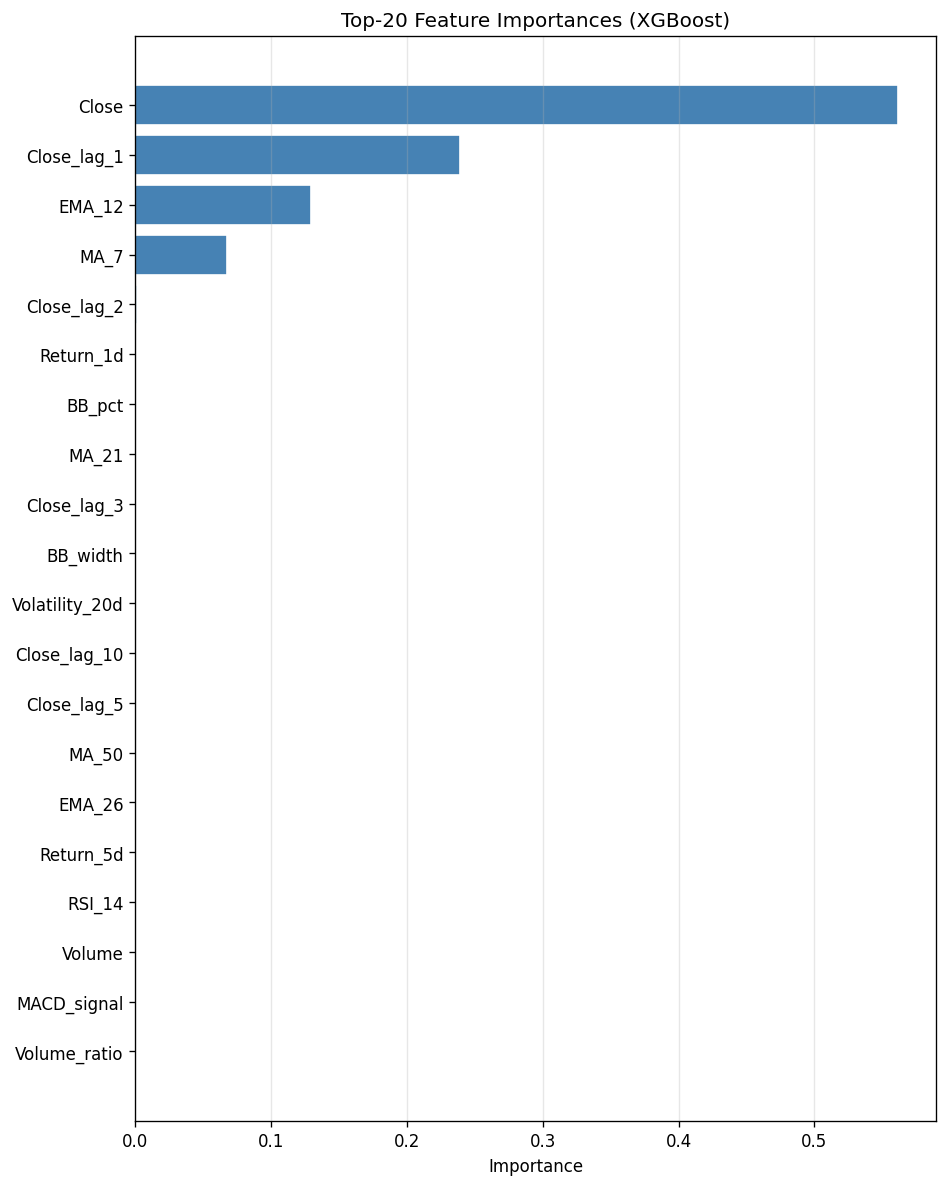

In [36]:
plot_feature_importance(xgb_model_tuned, FEATURE_COLS)

### 7d · Residual Diagnostics

A good model has residuals that are **centred at zero, homoscedastic (constant variance), and uncorrelated**. Patterns in the residual plot indicate unexploited structure.

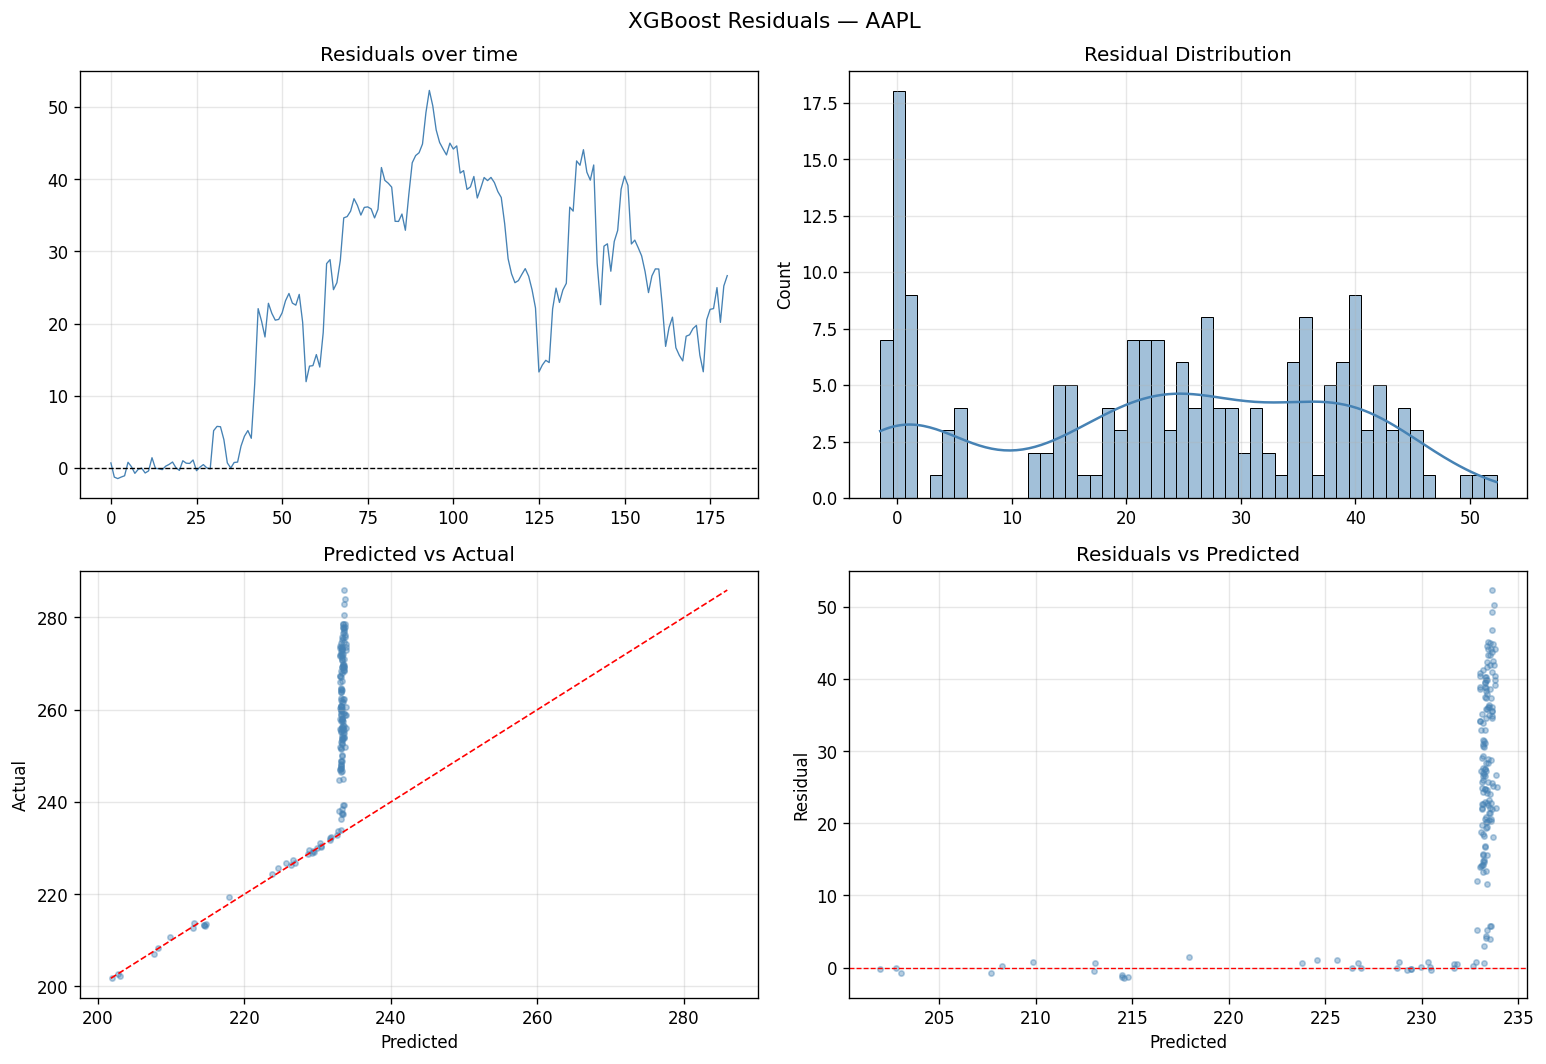

In [37]:
plot_residuals(xgb_true, xgb_pred_tuned, title=f'XGBoost Residuals — {TICKER}')

### 7e · LSTM Training Curves

Convergence plots confirm that training and validation loss both decrease and that early stopping triggered at the right epoch (gap between train and val curves indicates overfitting).

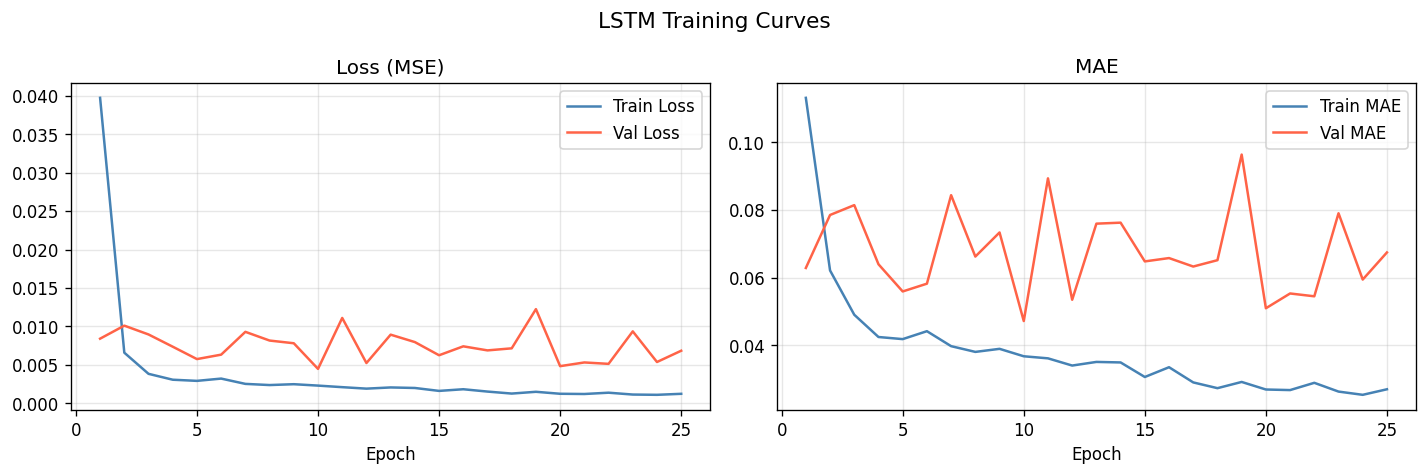

In [38]:
plot_loss_curves(lstm_history_tuned)

### 7f · Interactive Charts (Plotly)

Plotly charts are **fully interactive** — zoom in/out, pan, and hover over any data point to see exact values.

**Tips:**
- Double-click the chart to reset zoom
- Click legend items to toggle traces on/off
- Drag a box on the chart to zoom into a specific date range

> If a chart does not appear below (shows blank or error), open a terminal and run:
> ```
> pip install plotly nbformat
> ```
> Then restart the kernel and re-run this cell.


In [39]:
plot_candlestick(df, ticker=TICKER, last_n_days=252)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [40]:
plot_forecast_interactive(xgb_true, xgb_pred_tuned, dates=test_dates, title=f'XGBoost Interactive — {TICKER}')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed